# Fast Degree-to-Job Market Analysis

Uses preprocessed data (Kneedle already applied) for module relevance and breadth analysis. Results saved for batch processing of all 21 degrees.

**See `complete_analysis_full.ipynb` for preprocessing methodology.**

## Configuration & File Paths

In [ ]:
import os
from pathlib import Path

# Get notebook directory and construct data path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
BASE_DATA_PATH = os.path.join(NOTEBOOK_DIR, "..", "..", "Downloads", "DSA4264 Data")

# Paths
COURSES_DIR = os.path.join(BASE_DATA_PATH, "NUS-SMU-SUTD Courses")
MATCHES_DIR = os.path.join(BASE_DATA_PATH, "Jobs by courses")
JOBS_PARQUET = os.path.join(BASE_DATA_PATH, "processed_jobs_dual_embeddings.parquet")

TARGET_DEGREE = "data_sci_analytics"
TARGET_SCHOOL = "nus"

ALL_MODULES_PARQUET = os.path.join(COURSES_DIR, f"all_{TARGET_SCHOOL}_modules_embedded.parquet")
JOBS_CSV = os.path.join(MATCHES_DIR, f"{TARGET_SCHOOL}_{TARGET_DEGREE}_matches.csv")
DEGREE_OUTPUT_DIR = os.path.join("..", "outputs", "analysis_results", TARGET_SCHOOL, TARGET_DEGREE)
VIZ_DIR = os.path.join(DEGREE_OUTPUT_DIR, "visualizations")

# Create directories
os.makedirs(DEGREE_OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Data path: {BASE_DATA_PATH}")
print(f"Target: {TARGET_SCHOOL.upper()} {TARGET_DEGREE}")
print(f"Job embeddings: {JOBS_PARQUET}")

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# School brand colors
SCHOOL_COLORS = {
    "nus": {"primary": "#EF7C00", "secondary": "#003D7C"},
    "smu": {"primary": "#8A704C", "secondary": "#141C52"},
    "sutd": {"primary": "#A01735", "secondary": "#000000"}
}

print("All libraries imported!")

---
# PART 1: Loading Preprocessed Data

CSV files in "Jobs by courses/" are already Kneedle-filtered during preprocessing.

---
# PART 2: Load Data

In [ ]:
print("PART 2: LOADING PREPROCESSED DATA (KNEEDLE ALREADY APPLIED)")

# Load PREPROCESSED job matches for this degree (Kneedle already applied!)
dsa_jobs_csv = pd.read_csv(JOBS_CSV)
print(f"Loaded {len(dsa_jobs_csv)} FILTERED job matches for {TARGET_DEGREE}")
print(f"  (These jobs were selected by Kneedle during preprocessing)")

# Load parquet and filter to only the jobs in the CSV
all_jobs_df = pd.read_parquet(JOBS_PARQUET)
embedding_col = 'embedding_mpnet' if 'embedding_mpnet' in all_jobs_df.columns else [c for c in all_jobs_df.columns if 'embed' in c.lower()][0]

# Filter parquet to only jobs that are in our CSV
dsa_jobs_df = all_jobs_df[all_jobs_df['title'].isin(dsa_jobs_csv['title'])].copy()

# DEDUPLICATE by title (keep first occurrence) to avoid inflating job count
dsa_jobs_df = dsa_jobs_df.drop_duplicates(subset='title', keep='first')
print(f"Matched {len(dsa_jobs_df)} jobs with embeddings from parquet")

# Add similarity scores from CSV
dsa_jobs_df = dsa_jobs_df.merge(
    dsa_jobs_csv[['title', 'avg_similarity', 'max_similarity']], 
    on='title', 
    how='left'
)

# Rename columns if needed
if 'avg_similarity' in dsa_jobs_df.columns and 'semantic_avg_similarity' not in dsa_jobs_df.columns:
    dsa_jobs_df['semantic_avg_similarity'] = dsa_jobs_df['avg_similarity']
if 'max_similarity' in dsa_jobs_df.columns and 'semantic_max_similarity' not in dsa_jobs_df.columns:
    dsa_jobs_df['semantic_max_similarity'] = dsa_jobs_df['max_similarity']

# Load modules with embeddings
all_modules_df = pd.read_parquet(ALL_MODULES_PARQUET)
modules_df = all_modules_df[all_modules_df['course'].str.lower() == TARGET_DEGREE.lower()].copy()

# Extract embeddings
module_embedding_col = [c for c in modules_df.columns if 'embed' in c.lower()][0]
module_embeddings = np.array(modules_df[module_embedding_col].tolist())

print(f"Loaded {len(modules_df)} modules")
print(f"  Module embeddings shape: {module_embeddings.shape}")

print(f"\nKNEEDLE FILTERING: ALREADY DONE!")
print(f"The {len(dsa_jobs_df)} jobs in this CSV were selected by Kneedle during preprocessing.")
print(f"Cutoff similarity: {dsa_jobs_df['semantic_avg_similarity'].min():.4f}")
print(f"See complete_analysis_full.ipynb for Kneedle methodology details.\n")

---
# PART 3: Module Analysis

In [ ]:
print("\nPART 3: MODULE RELEVANCE & BREADTH ANALYSIS")

# Calculate similarity: modules x DSA jobs
dsa_job_embeddings_matrix = np.stack(dsa_jobs_df[embedding_col].values)
similarity_matrix = cosine_similarity(module_embeddings, dsa_job_embeddings_matrix)

# Data-driven threshold: use 60th percentile of module-job similarities
match_threshold = np.percentile(similarity_matrix.flatten(), 60)

print(f"Threshold for breadth (60th percentile): {match_threshold:.3f}")

module_analysis = []
for i, (idx, module) in enumerate(modules_df.iterrows()):
    module_similarities = similarity_matrix[i]

    # Relevance (Depth): average similarity to all DSA jobs
    relevance_score = np.mean(module_similarities)
    
    # Breadth: number of jobs matched above threshold
    matching_jobs_mask = module_similarities > match_threshold
    num_matching_jobs = matching_jobs_mask.sum()
    breadth_score = num_matching_jobs
    
    # Max similarity (best single job match)
    max_similarity = np.max(module_similarities)

    module_analysis.append({
        'module_code': module['code'],
        'module_title': module.get('title', ''),
        'relevance_score': relevance_score,
        'breadth_score': breadth_score,
        'max_similarity': max_similarity,
        'num_matching_jobs': num_matching_jobs
    })

module_analysis_df = pd.DataFrame(module_analysis)

print("\nTop 10 Most Relevant Modules (Depth):")
top_relevant = module_analysis_df.nlargest(10, 'relevance_score')
for idx, row in top_relevant.iterrows():
    print(f"  {row['module_code']}: {row['relevance_score']:.3f} (breadth: {row['breadth_score']} jobs matched)")

print("\nTop 10 Broadest Modules (Shows How Versatile a module is):")
top_broad = module_analysis_df.nlargest(10, 'breadth_score')
for idx, row in top_broad.iterrows():
    print(f"  {row['module_code']}: {row['breadth_score']} jobs matched (relevance: {row['relevance_score']:.3f})")

In [ ]:
# OVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY
market_similarity_matrix = similarity_matrix  # Already calculated for filtered jobs

print("\nOVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY")

# ANALYSIS 1: UNION-BASED (Peak Qualification)
max_similarities_per_job = np.max(market_similarity_matrix, axis=0)
union_relevance = np.mean(max_similarities_per_job)

# ANALYSIS 2: COLLECTIVE COVERAGE (Top-K Subset)
top_k = 5
top_k_indices = np.argsort(market_similarity_matrix, axis=0)[-top_k:, :]
top_k_scores = np.take_along_axis(market_similarity_matrix, top_k_indices, axis=0)
collective_score_per_job = np.mean(top_k_scores, axis=0)
combined_relevance = np.mean(collective_score_per_job)

# ANALYSIS 3: REFINED SKILL BREADTH (Market-Wide)
unique_elements, counts = np.unique(top_k_indices, return_counts=True)
module_contribution_counts = np.zeros(len(modules_df))
module_contribution_counts[unique_elements] = counts

active_threshold = max(1, len(dsa_jobs_df) * 0.01) 
active_modules_count = (module_contribution_counts >= active_threshold).sum()
degree_utilization = (active_modules_count / len(modules_df)) * 100

useful_modules_count = ( (market_similarity_matrix >= 0.30).sum(axis=1) >= active_threshold ).sum()
niche_utilization = (useful_modules_count / len(modules_df)) * 100

# PREPARATION CATEGORIES (Default Thresholds)
well_prepared_threshold = 0.40
moderate_threshold = 0.30

well_prepared_jobs = (collective_score_per_job >= well_prepared_threshold).sum()
moderately_prepared_jobs = ((collective_score_per_job >= moderate_threshold) & (collective_score_per_job < well_prepared_threshold)).sum()
underprepared_jobs = len(dsa_jobs_df) - well_prepared_jobs - moderately_prepared_jobs

# RESULTS
print(f"Peak Qualification (Union):   {union_relevance:.3f}")
print(f"Collective Relevance (Top-5): {combined_relevance:.3f}")
print(f"Active Core Utilization:      {degree_utilization:.1f}%")
print(f"Supporting Skill Breadth:     {niche_utilization:.1f}%")

print(f"\n[Thresholds: Well >= {well_prepared_threshold:.2f}, Moderate >= {moderate_threshold:.2f}]")
print(f"Highly Prepared Jobs:        {well_prepared_jobs} ({ (well_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"Moderately Prepared Jobs:    {moderately_prepared_jobs} ({ (moderately_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"Under-prepared Jobs:         {underprepared_jobs} ({ (underprepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"\nNote: Batch analysis uses global thresholds from all degrees")

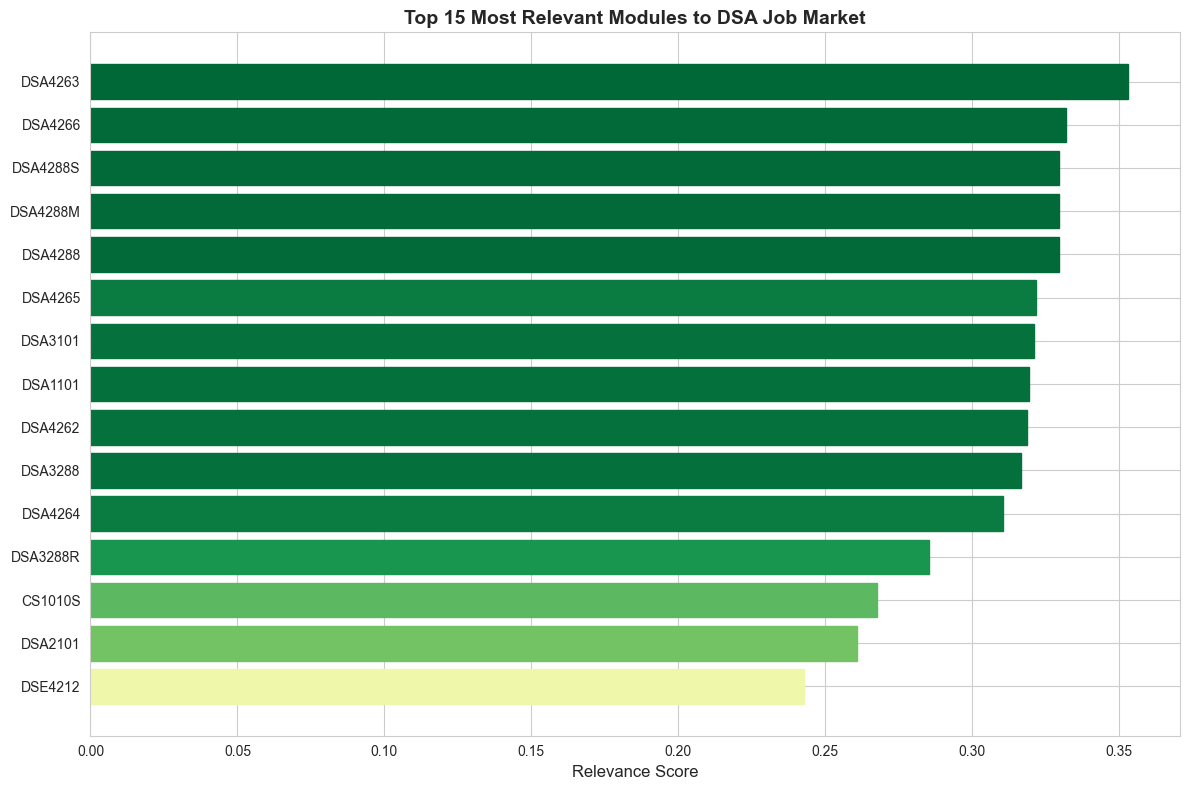

Saved: top_15_relevant_modules.png


In [ ]:
# 2. Top 15 Most Relevant Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_relevant = module_analysis_df.nlargest(15, 'relevance_score').sort_values('relevance_score')
bars = ax.barh(range(len(top_15_relevant)), top_15_relevant['relevance_score'])
ax.set_yticks(range(len(top_15_relevant)))
ax.set_yticklabels(top_15_relevant['module_code'])
ax.set_xlabel('Relevance Score', fontsize=12)
ax.set_title('Top 15 Most Relevant Modules to DSA Job Market', fontsize=14, fontweight='bold')

# Color bars by breadth
colors = plt.cm.RdYlGn(top_15_relevant['breadth_score'] / top_15_relevant['breadth_score'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_15_relevant_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_relevant_modules.png")

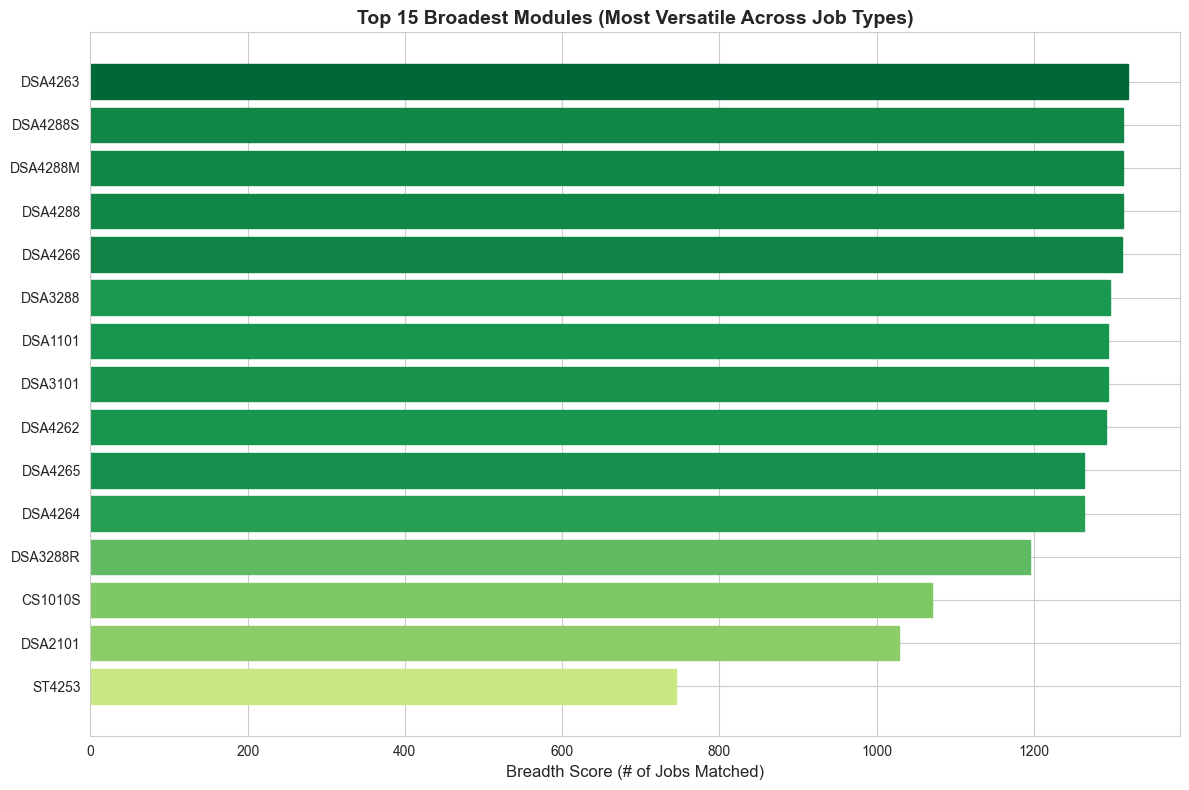

Saved: top_15_broadest_modules.png


In [ ]:
# 3. Top 15 Broadest Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_broad = module_analysis_df.nlargest(15, 'breadth_score').sort_values('breadth_score')
bars = ax.barh(range(len(top_15_broad)), top_15_broad['breadth_score'])
ax.set_yticks(range(len(top_15_broad)))
ax.set_yticklabels(top_15_broad['module_code'])
ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_title('Top 15 Broadest Modules (Most Versatile Across Job Types)', fontsize=14, fontweight='bold')

# Color bars by relevance
colors = plt.cm.RdYlGn(top_15_broad['relevance_score'] / top_15_broad['relevance_score'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_15_broadest_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_broadest_modules.png")

---
# PART 4: Visualizations

In [ ]:
print("\nGENERATING MODULE VISUALIZATIONS")

# 1. Scatter Plot: Breadth vs Relevance
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    module_analysis_df['breadth_score'], 
    module_analysis_df['relevance_score'],
    s=module_analysis_df['num_matching_jobs'] * 2,
    alpha=0.6,
    c=module_analysis_df['breadth_score'],
    cmap='viridis'
)

# Annotate top modules
top_modules_to_label = module_analysis_df.nlargest(15, 'relevance_score')
for idx, row in top_modules_to_label.iterrows():
    ax.annotate(
        row['module_code'], 
        (row['breadth_score'], row['relevance_score']),
        fontsize=8,
        alpha=0.7
    )

ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_ylabel('Relevance Score (Avg Similarity)', fontsize=12)
ax.set_title(f'{TARGET_SCHOOL.upper()} {TARGET_DEGREE}: Module Breadth vs Relevance', 
             fontsize=14, fontweight='bold', color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'])
plt.colorbar(scatter, label='Breadth Score')
plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'module_breadth_vs_relevance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: module_breadth_vs_relevance.png")

In [ ]:
# 2. Top 15 Most Relevant Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_relevant = module_analysis_df.nlargest(15, 'relevance_score').sort_values('relevance_score')
bars = ax.barh(range(len(top_15_relevant)), top_15_relevant['relevance_score'], 
               color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'], alpha=0.7)
ax.set_yticks(range(len(top_15_relevant)))
ax.set_yticklabels(top_15_relevant['module_code'])
ax.set_xlabel('Relevance Score', fontsize=12)
ax.set_title(f'Top 15 Most Relevant Modules - {TARGET_SCHOOL.upper()} {TARGET_DEGREE}', 
             fontsize=14, fontweight='bold', color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'])

plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'top_15_relevant_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_relevant_modules.png")

In [ ]:
# 3. Top 15 Broadest Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_broad = module_analysis_df.nlargest(15, 'breadth_score').sort_values('breadth_score')
bars = ax.barh(range(len(top_15_broad)), top_15_broad['breadth_score'],
               color=SCHOOL_COLORS[TARGET_SCHOOL]['secondary'], alpha=0.7)
ax.set_yticks(range(len(top_15_broad)))
ax.set_yticklabels(top_15_broad['module_code'])
ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_title(f'Top 15 Broadest Modules - {TARGET_SCHOOL.upper()} {TARGET_DEGREE}', 
             fontsize=14, fontweight='bold', color=SCHOOL_COLORS[TARGET_SCHOOL]['secondary'])

plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'top_15_broadest_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_broadest_modules.png")

In [ ]:
# Batch mode configuration (skip if only analyzing single degree)
# Uncomment if you have config.py and analysis_utils.py for batch processing

# import sys
# sys.path.append('..')
# import config
# import analysis_utils as au
# from tqdm import tqdm

# VIZ_MODE = 'top_n'
# TOP_N = 10

print("Batch configuration cell (currently disabled)")
print("For single degree analysis, this cell can be skipped")

In [ ]:
# 4. Degree Preparation Distribution Histogram (Dual Analysis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: Union-based (Best Single Module)
union_well = np.percentile(max_similarities_per_job, 67)
union_mod = np.percentile(max_similarities_per_job, 33)

ax1.hist(max_similarities_per_job, bins=50, edgecolor='black', alpha=0.7, 
         color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'])
ax1.axvline(union_well, color='green', linestyle='--', linewidth=2, label=f'Well Prepared (>={union_well:.3f})')
ax1.axvline(union_mod, color='orange', linestyle='--', linewidth=2, label=f'Moderate (>={union_mod:.3f})')
ax1.axvline(union_relevance, color='red', linestyle='-', linewidth=2, label=f'Mean: {union_relevance:.3f}')
ax1.set_xlabel('Best Module Match (Max Similarity)', fontsize=11)
ax1.set_ylabel('Number of Jobs', fontsize=11)
ax1.set_title('Union-Based: Best Single Module', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Right: Combined Coverage (Top-5)
ax2.hist(collective_score_per_job, bins=50, edgecolor='black', alpha=0.7, 
         color=SCHOOL_COLORS[TARGET_SCHOOL]['secondary'])
ax2.axvline(well_prepared_threshold, color='green', linestyle='--', linewidth=2, 
            label=f'Well Prepared (≥{well_prepared_threshold:.2f})')
ax2.axvline(moderate_threshold, color='orange', linestyle='--', linewidth=2, 
            label=f'Moderate (≥{moderate_threshold:.2f})')
ax2.axvline(combined_relevance, color='red', linestyle='-', linewidth=2, label=f'Mean: {combined_relevance:.3f}')
ax2.set_xlabel('Top-5 Module Coverage Score', fontsize=11)
ax2.set_ylabel('Number of Jobs', fontsize=11)
ax2.set_title('Combined Coverage: Top-5 Modules', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'degree_preparation_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: degree_preparation_distribution.png")

---
# PART 5: Save Results

In [ ]:
print("\nSAVING RESULTS")

# Save module analysis
module_analysis_output = os.path.join(DEGREE_OUTPUT_DIR, "module_analysis_results.csv")
module_analysis_df.to_csv(module_analysis_output, index=False)
print(f"Saved module analysis: {module_analysis_output}")

# Save DSA jobs
jobs_output = os.path.join(DEGREE_OUTPUT_DIR, "relevant_jobs.csv")
save_columns = ['title', 'description', 'semantic_avg_similarity']
if 'companyName' in dsa_jobs_df.columns:
    save_columns.insert(1, 'companyName')
elif 'company' in dsa_jobs_df.columns:
    save_columns.insert(1, 'company')
dsa_jobs_df[[col for col in save_columns if col in dsa_jobs_df.columns]].to_csv(jobs_output, index=False)
print(f"Saved relevant jobs: {jobs_output}")

# Save degree summary
degree_summary = {
    'degree': TARGET_DEGREE,
    'school': TARGET_SCHOOL,
    'total_modules': len(modules_df),
    'market_size': len(dsa_jobs_df),
    'market_cutoff_score': dsa_jobs_df['semantic_avg_similarity'].min(),
    'union_relevance': union_relevance,
    'collective_relevance': combined_relevance,
    'active_core_utilization_pct': degree_utilization,
    'supporting_skill_breadth_pct': niche_utilization,
    'well_prepared_jobs': well_prepared_jobs,
    'well_prepared_pct': (well_prepared_jobs / len(dsa_jobs_df)) * 100,
    'moderately_prepared_jobs': moderately_prepared_jobs,
    'moderately_prepared_pct': (moderately_prepared_jobs / len(dsa_jobs_df)) * 100,
    'underprepared_jobs': underprepared_jobs,
    'underprepared_pct': (underprepared_jobs / len(dsa_jobs_df)) * 100,
    'top_module': module_analysis_df.nlargest(1, 'relevance_score').iloc[0]['module_code'],
    'top_module_relevance': module_analysis_df['relevance_score'].max(),
    'avg_module_relevance': module_analysis_df['relevance_score'].mean(),
}

summary_df = pd.DataFrame([degree_summary])
summary_output = os.path.join(DEGREE_OUTPUT_DIR, "degree_summary.csv")
summary_df.to_csv(summary_output, index=False)
print(f"Saved degree summary: {summary_output}")

print(f"\nSINGLE DEGREE ANALYSIS COMPLETE!")
print(f"Degree: {TARGET_SCHOOL.upper()} {TARGET_DEGREE}")
print(f"Market Size: {len(dsa_jobs_df):,} jobs")
print(f"Union Relevance: {union_relevance:.3f}")
print(f"Collective Relevance: {combined_relevance:.3f}")
print(f"Well Prepared: {well_prepared_jobs} ({(well_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")

---
# PART 6: Multi-School Batch Analysis

**Run cells 21A-21B to analyze all 21 degrees** and generate comparison data.

Then run cells 24-35 to see cross-degree visualizations and insights!

---
# PART 7: Cross-Degree Comparison & Visualizations

**Prerequisites:** Run batch processing cells above first to generate comparison data.

In [ ]:
# BATCH PROCESSING: ALL 21 DEGREES
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Define all degrees with metadata
DEGREES_CONFIG = [
    # NUS
    {"school": "nus", "degree": "accountancy", "category": "Business"},
    {"school": "nus", "degree": "biomedical_engineering", "category": "Engineering"},
    {"school": "nus", "degree": "business_analytics", "category": "Business"},
    {"school": "nus", "degree": "chemical_engineering", "category": "Engineering"},
    {"school": "nus", "degree": "civil_engineering", "category": "Engineering"},
    {"school": "nus", "degree": "data_sci_analytics", "category": "Data Science"},
    {"school": "nus", "degree": "industrial_design", "category": "Design"},
    {"school": "nus", "degree": "information_systems", "category": "Computing"},
    {"school": "nus", "degree": "landscape_architecture", "category": "Design"},
    {"school": "nus", "degree": "real_estate", "category": "Business"},
    # SMU
    {"school": "smu", "degree": "accountancy", "category": "Business"},
    {"school": "smu", "degree": "business", "category": "Business"},
    {"school": "smu", "degree": "computinglaw", "category": "Computing"},
    {"school": "smu", "degree": "economics", "category": "Business"},
    {"school": "smu", "degree": "information_systems", "category": "Computing"},
    {"school": "smu", "degree": "social_sciences", "category": "Social Sciences"},
    # SUTD
    {"school": "sutd", "degree": "architecture", "category": "Design"},
    {"school": "sutd", "degree": "computer_sci", "category": "Computing"},
    {"school": "sutd", "degree": "design_ai", "category": "Design"},
    {"school": "sutd", "degree": "engineering_product", "category": "Engineering"},
    {"school": "sutd", "degree": "engineering_systems", "category": "Engineering"},
]

print(f"Found {len(DEGREES_CONFIG)} degrees to process\n")

# Storage for all results
all_results = []

# Process each degree
for deg_config in tqdm(DEGREES_CONFIG, desc="Processing degrees"):
    school = deg_config["school"]
    degree = deg_config["degree"]
    category = deg_config["category"]
    
    try:
        print(f"\nProcessing: {school.upper()} - {degree}")
        
        # Load job matches CSV
        jobs_csv_path = os.path.join(MATCHES_DIR, f"{school}_{degree}_matches.csv")
        if not os.path.exists(jobs_csv_path):
            print(f"  Skipping: {jobs_csv_path} not found")
            continue
            
        jobs_csv = pd.read_csv(jobs_csv_path)
        print(f"  Loaded {len(jobs_csv)} jobs from CSV")
        
        # Load parquet and match jobs
        all_jobs = pd.read_parquet(JOBS_PARQUET)
        embed_col = 'embedding_mpnet' if 'embedding_mpnet' in all_jobs.columns else [c for c in all_jobs.columns if 'embed' in c.lower()][0]
        
        jobs_df = all_jobs[all_jobs['title'].isin(jobs_csv['title'])].copy()
        jobs_df = jobs_df.drop_duplicates(subset='title', keep='first')
        
        jobs_df = jobs_df.merge(
            jobs_csv[['title', 'avg_similarity', 'max_similarity']], 
            on='title', how='left'
        )
        jobs_df['semantic_avg_similarity'] = jobs_df['avg_similarity']
        jobs_df['semantic_max_similarity'] = jobs_df['max_similarity']
        
        print(f"  Matched {len(jobs_df)} jobs with embeddings")
        
        # Load modules
        modules_parquet = os.path.join(COURSES_DIR, f"all_{school}_modules_embedded.parquet")
        if not os.path.exists(modules_parquet):
            print(f"  Skipping: {modules_parquet} not found")
            continue
            
        all_mods = pd.read_parquet(modules_parquet)
        mods_df = all_mods[all_mods['course'].str.lower() == degree.lower()].copy()
        
        if len(mods_df) == 0:
            print(f"  No modules found for {degree}")
            continue
            
        mod_embed_col = [c for c in mods_df.columns if 'embed' in c.lower()][0]
        mod_embeddings = np.array(mods_df[mod_embed_col].tolist())
        
        print(f"  Loaded {len(mods_df)} modules")
        
        # Calculate similarity matrix
        job_embeddings = np.stack(jobs_df[embed_col].values)
        sim_matrix = cosine_similarity(mod_embeddings, job_embeddings)
        
        # Union relevance (best single module per job)
        max_sims_per_job = np.max(sim_matrix, axis=0)
        union_rel = np.mean(max_sims_per_job)
        
        # Collective relevance (top-5 modules per job)
        top_k = 5
        top_k_idx = np.argsort(sim_matrix, axis=0)[-top_k:, :]
        top_k_sims = np.take_along_axis(sim_matrix, top_k_idx, axis=0)
        collective_per_job = np.mean(top_k_sims, axis=0)
        combined_rel = np.mean(collective_per_job)
        
        # Utilization metrics
        unique_elems, counts = np.unique(top_k_idx, return_counts=True)
        mod_contrib = np.zeros(len(mods_df))
        mod_contrib[unique_elems] = counts
        
        active_thresh = max(1, len(jobs_df) * 0.01)
        active_mods = (mod_contrib >= active_thresh).sum()
        deg_util = (active_mods / len(mods_df)) * 100
        
        useful_mods = ((sim_matrix >= 0.30).sum(axis=1) >= active_thresh).sum()
        niche_util = (useful_mods / len(mods_df)) * 100
        
        # Preparation categories (will recalculate with global thresholds later)
        well_thresh = 0.40
        mod_thresh = 0.30
        
        well_prep = (collective_per_job >= well_thresh).sum()
        mod_prep = ((collective_per_job >= mod_thresh) & (collective_per_job < well_thresh)).sum()
        under_prep = len(jobs_df) - well_prep - mod_prep
        
        # Store results
        result = {
            'degree': degree,
            'school': school,
            'category': category,
            'degree_full_name': f"{school.upper()} - {degree.replace('_', ' ').title()}",
            'total_modules': len(mods_df),
            'market_size': len(jobs_df),
            'market_cutoff_score': jobs_df['semantic_avg_similarity'].min(),
            'union_relevance': union_rel,
            'collective_relevance': combined_rel,
            'active_core_utilization_pct': deg_util,
            'supporting_skill_breadth_pct': niche_util,
            'well_prepared_jobs': well_prep,
            'well_prepared_pct': (well_prep / len(jobs_df)) * 100,
            'moderately_prepared_jobs': mod_prep,
            'moderately_prepared_pct': (mod_prep / len(jobs_df)) * 100,
            'underprepared_jobs': under_prep,
            'underprepared_pct': (under_prep / len(jobs_df)) * 100,
        }
        
        all_results.append(result)
        print(f"  Analysis complete")
        print(f"    Union: {union_rel:.3f}, Collective: {combined_rel:.3f}")
        print(f"    Well prepared: {well_prep} ({(well_prep/len(jobs_df))*100:.1f}%)")
        
    except Exception as e:
        print(f"  Error processing {school} {degree}: {str(e)}")
        continue

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)

# Calculate global thresholds (67th and 33rd percentiles)
all_collective_scores = []
for deg_config in DEGREES_CONFIG:
    school = deg_config["school"]
    degree = deg_config["degree"]
    
    try:
        jobs_csv_path = os.path.join(MATCHES_DIR, f"{school}_{degree}_matches.csv")
        if not os.path.exists(jobs_csv_path):
            continue
            
        jobs_csv = pd.read_csv(jobs_csv_path)
        all_jobs = pd.read_parquet(JOBS_PARQUET)
        embed_col = 'embedding_mpnet' if 'embedding_mpnet' in all_jobs.columns else [c for c in all_jobs.columns if 'embed' in c.lower()][0]
        
        jobs_df = all_jobs[all_jobs['title'].isin(jobs_csv['title'])].copy()
        jobs_df = jobs_df.drop_duplicates(subset='title', keep='first')
        
        modules_parquet = os.path.join(COURSES_DIR, f"all_{school}_modules_embedded.parquet")
        all_mods = pd.read_parquet(modules_parquet)
        mods_df = all_mods[all_mods['course'].str.lower() == degree.lower()].copy()
        
        if len(mods_df) == 0:
            continue
            
        mod_embed_col = [c for c in mods_df.columns if 'embed' in c.lower()][0]
        mod_embeddings = np.array(mods_df[mod_embed_col].tolist())
        job_embeddings = np.stack(jobs_df[embed_col].values)
        
        sim_matrix = cosine_similarity(mod_embeddings, job_embeddings)
        top_k = 5
        top_k_idx = np.argsort(sim_matrix, axis=0)[-top_k:, :]
        top_k_sims = np.take_along_axis(sim_matrix, top_k_idx, axis=0)
        collective_per_job = np.mean(top_k_sims, axis=0)
        
        all_collective_scores.extend(collective_per_job.tolist())
    except:
        continue

# Calculate global thresholds
global_well_thresh = np.percentile(all_collective_scores, 67)
global_mod_thresh = np.percentile(all_collective_scores, 33)

print(f"\nGLOBAL THRESHOLDS CALCULATED")
print(f"Well Prepared: >= {global_well_thresh:.4f} (67th percentile)")
print(f"Moderate: >= {global_mod_thresh:.4f} (33rd percentile)")
print(f"Under-prepared: < {global_mod_thresh:.4f}")

# Save thresholds
global_thresh_df = pd.DataFrame([{
    'well_prepared_threshold': global_well_thresh,
    'moderate_threshold': global_mod_thresh
}])

# Create summary output directory
summary_dir = Path("../outputs/analysis_results/summary")
summary_dir.mkdir(parents=True, exist_ok=True)

# Save files
comparison_df.to_csv(summary_dir / "all_degrees_comparison.csv", index=False)
global_thresh_df.to_csv(summary_dir / "global_thresholds.csv", index=False)

print(f"\nBATCH PROCESSING COMPLETE!")
print(f"Processed: {len(comparison_df)} degrees")
print(f"Saved to: {summary_dir}")
print(f"  - all_degrees_comparison.csv")
print(f"  - global_thresholds.csv")
print(f"\nYou can now run cells 25-35 for cross-degree analysis!\n")

# Load comparison data (generated by batch processing above)
from pathlib import Path

SUMMARY_OUTPUT_DIR = Path("../outputs/analysis_results/summary")
comparison_file = SUMMARY_OUTPUT_DIR / "all_degrees_comparison.csv"
global_thresholds_file = SUMMARY_OUTPUT_DIR / "global_thresholds.csv"

if comparison_file.exists() and global_thresholds_file.exists():
    comparison_data = pd.read_csv(comparison_file)
    global_thresholds = pd.read_csv(global_thresholds_file)
    print(f"Loaded comparison data: {len(comparison_data)} degrees")
    print(f"Global thresholds loaded")
    print(f"\nYou can now run cells 26-36 for cross-degree visualizations!")
else:
    comparison_data = None
    global_thresholds = None
    print("Batch comparison files not found")
    print(f"   Expected: {comparison_file}")
    print("   Please run the batch processing cell above first!")
    print("   Then re-run this cell to load the results.")

In [ ]:
# Load comparison data for cross-degree analysis (only if batch files exist)
from pathlib import Path

# Define paths without config.py
SUMMARY_OUTPUT_DIR = Path("../outputs/analysis_results/summary")
comparison_file = SUMMARY_OUTPUT_DIR / "all_degrees_comparison.csv"
global_thresholds_file = SUMMARY_OUTPUT_DIR / "global_thresholds.csv"

if comparison_file.exists() and global_thresholds_file.exists():
    comparison_data = pd.read_csv(comparison_file)
    global_thresholds = pd.read_csv(global_thresholds_file)
    print(f"✓ Loaded comparison data: {len(comparison_data)} degrees")
    print("  You can now run cells 24-35 for cross-degree analysis")
else:
    # Create dummy data so cells don't crash
    comparison_data = None
    global_thresholds = None
    print("⚠️  Batch comparison files not found")
    print(f"   Expected: {comparison_file}")
    print("   These are generated by running batch analysis on all 21 degrees")
    print("   For now, SKIP cells 24-35 (they need these files to work)")

## Top vs Bottom Performers

In [ ]:

#  Top 5 vs Bottom 5 comparison
import textwrap
# 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
# 
# Top 5
top5 = comparison_data.nlargest(5, 'well_prepared_pct')
# Wrap full degree name (including school)
top5_labels = ['\n'.join(textwrap.wrap(name, 35)) for name in top5['degree_full_name']]
# 
ax1.barh(range(len(top5)), top5['well_prepared_pct'], color='green', alpha=0.7)
ax1.set_yticks(range(len(top5)))
ax1.set_yticklabels(top5_labels, fontsize=11)
ax1.set_xlabel('Well Prepared %', fontsize=12)
ax1.set_title('Top 5 Degrees by Preparation Quality', fontsize=14, fontweight='bold')
ax1.axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100, color='red', linestyle='--', label='Global Threshold')
for i, (idx, row) in enumerate(top5.iterrows()):
    ax1.text(row['well_prepared_pct'] + 1, i, f"{row['well_prepared_pct']:.1f}%", va='center', fontsize=10)
ax1.legend()
# 
# Bottom 5
bottom5 = comparison_data.nsmallest(5, 'well_prepared_pct').sort_values('well_prepared_pct')
# Wrap full degree name (including school)
bottom5_labels = ['\n'.join(textwrap.wrap(name, 35)) for name in bottom5['degree_full_name']]
# 
ax2.barh(range(len(bottom5)), bottom5['well_prepared_pct'], color='red', alpha=0.7)
ax2.set_yticks(range(len(bottom5)))
ax2.set_yticklabels(bottom5_labels, fontsize=11)
ax2.set_xlabel('Well Prepared %', fontsize=12)
ax2.set_title('Bottom 5 Degrees by Preparation Quality', fontsize=14, fontweight='bold')
ax2.axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100, color='red', linestyle='--', label='Global Threshold')
for i, (idx, row) in enumerate(bottom5.iterrows()):
    ax2.text(row['well_prepared_pct'] + 0.5, i, f"{row['well_prepared_pct']:.1f}%", va='center', fontsize=10)
ax2.legend()
# 
plt.tight_layout()
plt.savefig(SUMMARY_OUTPUT_DIR / 'top5_vs_bottom5_degrees.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top5_vs_bottom5_degrees.png")

## School Comparison

/var/folders/wc/5cwlt66x6d12kf_tz4qkd_580000gn/T/ipykernel_73530/588438205.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(school_prep_data, labels=[s.upper() for s in schools], patch_artist=True)


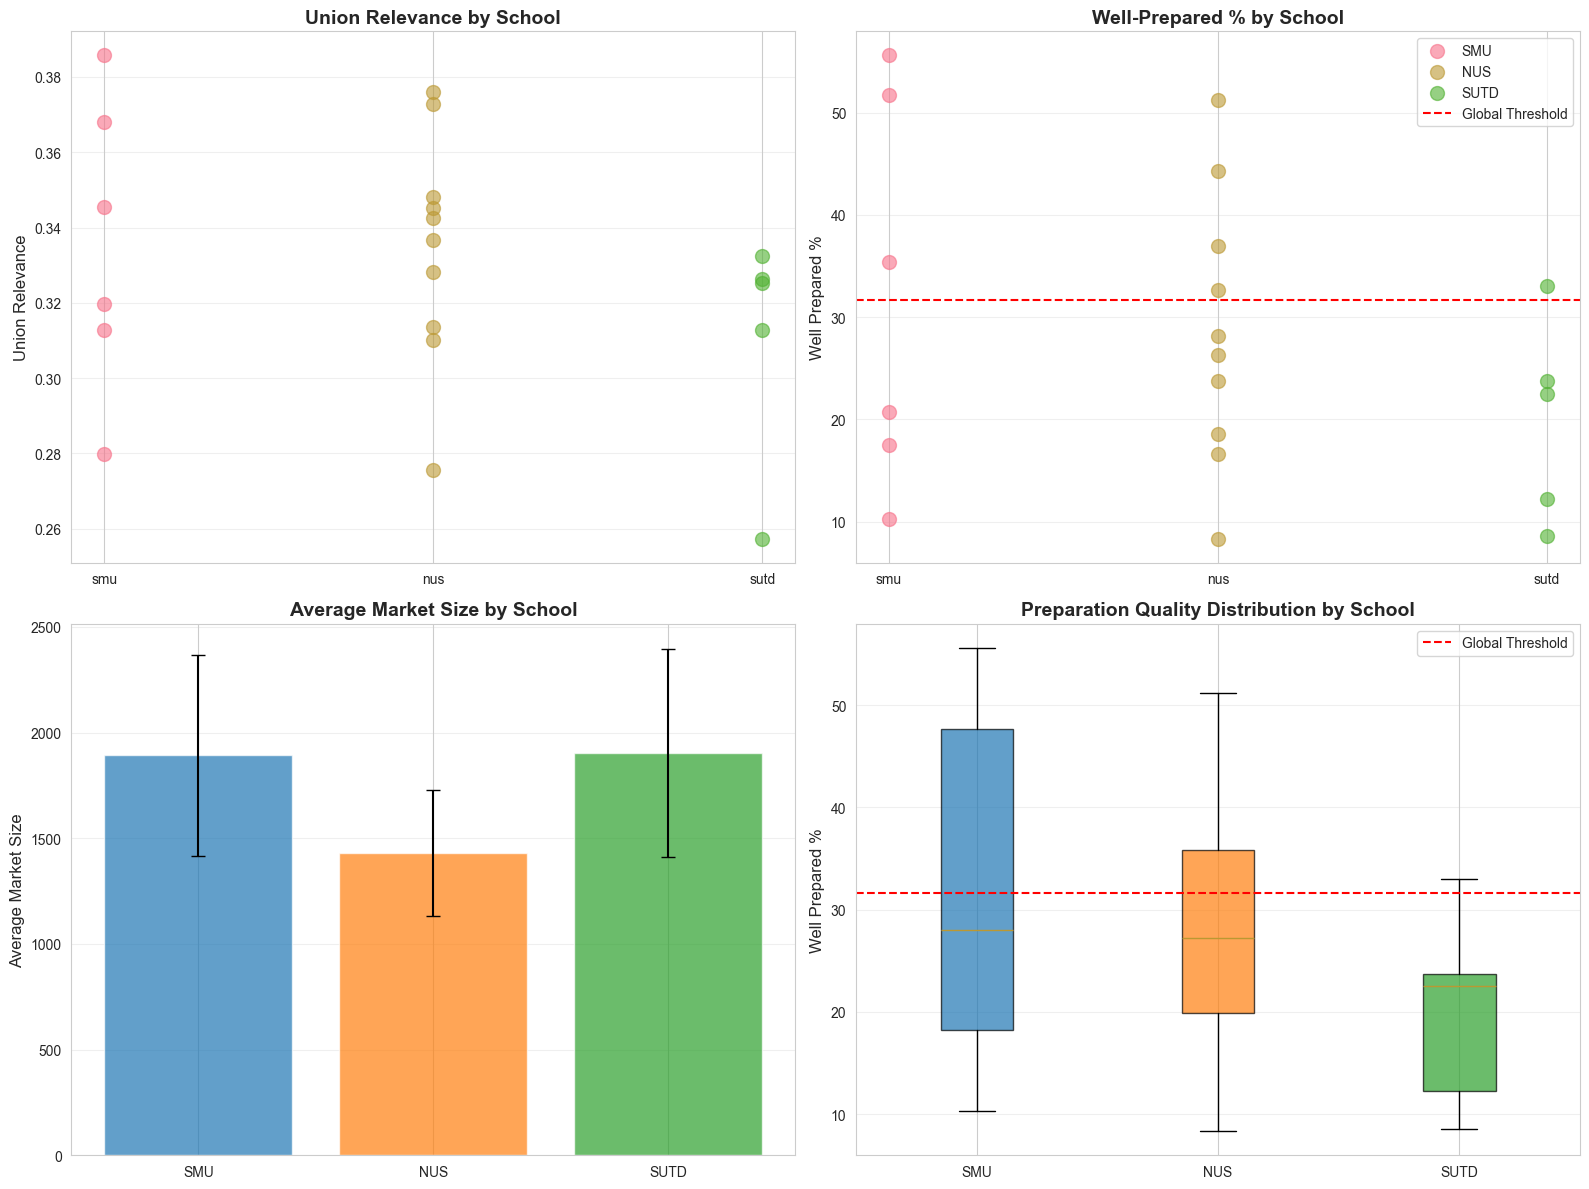

In [ ]:

# School comparison
school_stats = comparison_data.groupby('school').agg({
    'union_relevance': ['mean', 'std'],
    'collective_relevance': ['mean', 'std'],
    'well_prepared_pct': ['mean', 'std'],
    'market_size': 'mean'
}).round(3)
# 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 
# Plot 1: Union Relevance by School
schools = comparison_data['school'].unique()
for school in schools:
    school_data = comparison_data[comparison_data['school'] == school]
    axes[0, 0].scatter([school] * len(school_data), school_data['union_relevance'], 
                      s=100, alpha=0.6, label=school.upper())
axes[0, 0].set_ylabel('Union Relevance', fontsize=12)
axes[0, 0].set_title('Union Relevance by School', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
# 
# Plot 2: Well Prepared % by School  
for school in schools:
    school_data = comparison_data[comparison_data['school'] == school]
    axes[0, 1].scatter([school] * len(school_data), school_data['well_prepared_pct'],
                      s=100, alpha=0.6, label=school.upper())
axes[0, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100, 
                   color='red', linestyle='--', label='Global Threshold')
axes[0, 1].set_ylabel('Well Prepared %', fontsize=12)
axes[0, 1].set_title('Well-Prepared % by School', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].legend()
# 
# Plot 3: Market Size by School
school_market_data = comparison_data.groupby('school')['market_size'].agg(['mean', 'std', 'min', 'max'])
x_pos = range(len(schools))
axes[1, 0].bar(x_pos, school_market_data['mean'], yerr=school_market_data['std'],
              alpha=0.7, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([s.upper() for s in schools])
axes[1, 0].set_ylabel('Average Market Size', fontsize=12)
axes[1, 0].set_title('Average Market Size by School', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
# 
# Plot 4: Box plot of preparation quality
school_prep_data = [comparison_data[comparison_data['school'] == school]['well_prepared_pct'].values 
                    for school in schools]
bp = axes[1, 1].boxplot(school_prep_data, labels=[s.upper() for s in schools], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[1, 1].set_ylabel('Well Prepared %', fontsize=12)
axes[1, 1].set_title('Preparation Quality Distribution by School', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
# 
plt.tight_layout()
plt.show()

## Market Size vs Preparation Quality

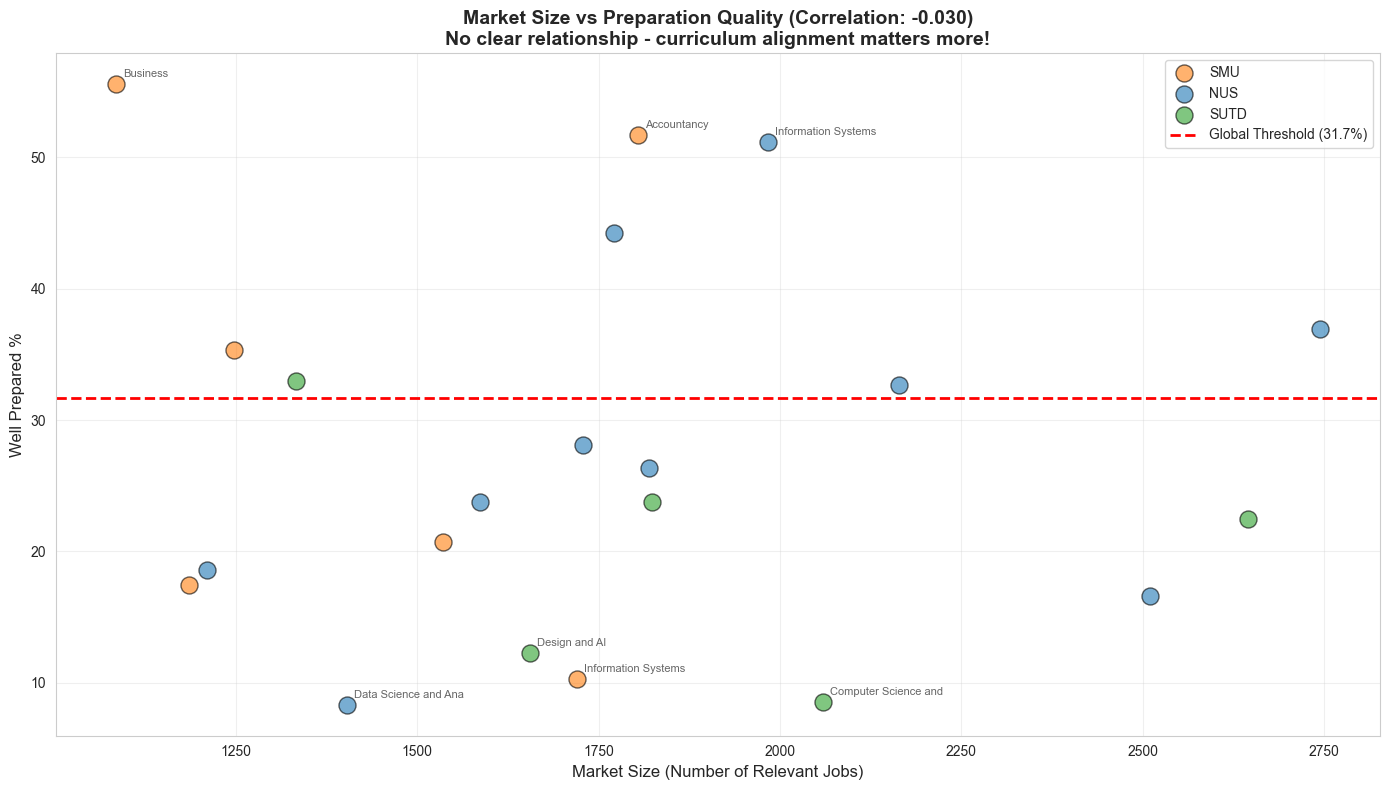

In [ ]:

# Market Size vs Preparation Quality Scatter
fig, ax = plt.subplots(figsize=(14, 8))
# 
# Color by school
colors = {'nus': '#1f77b4', 'smu': '#ff7f0e', 'sutd': '#2ca02c'}
for school in comparison_data['school'].unique():
    school_data = comparison_data[comparison_data['school'] == school]
    ax.scatter(school_data['market_size'], school_data['well_prepared_pct'],
              s=150, alpha=0.6, c=colors[school], label=school.upper(), edgecolors='black')
# 
# Add labels for notable degrees
for idx, row in comparison_data.iterrows():
    if row['well_prepared_pct'] > 45 or row['well_prepared_pct'] < 15:
        ax.annotate(row['degree_full_name'].split(' - ')[-1][:20], 
                   (row['market_size'], row['well_prepared_pct']),
                   fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')
# 
ax.axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
          color='red', linestyle='--', linewidth=2, label=f"Global Threshold ({global_thresholds.iloc[0]['well_prepared_threshold']*100:.1f}%)")
ax.set_xlabel('Market Size (Number of Relevant Jobs)', fontsize=12)
ax.set_ylabel('Well Prepared %', fontsize=12)
# 
# Calculate and show correlation in title
correlation = comparison_data['market_size'].corr(comparison_data['well_prepared_pct'])
ax.set_title(f'Market Size vs Preparation Quality (Correlation: {correlation:.3f})\nNo clear relationship - curriculum alignment matters more!', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
# 
plt.tight_layout()
plt.show()

## Category Patterns

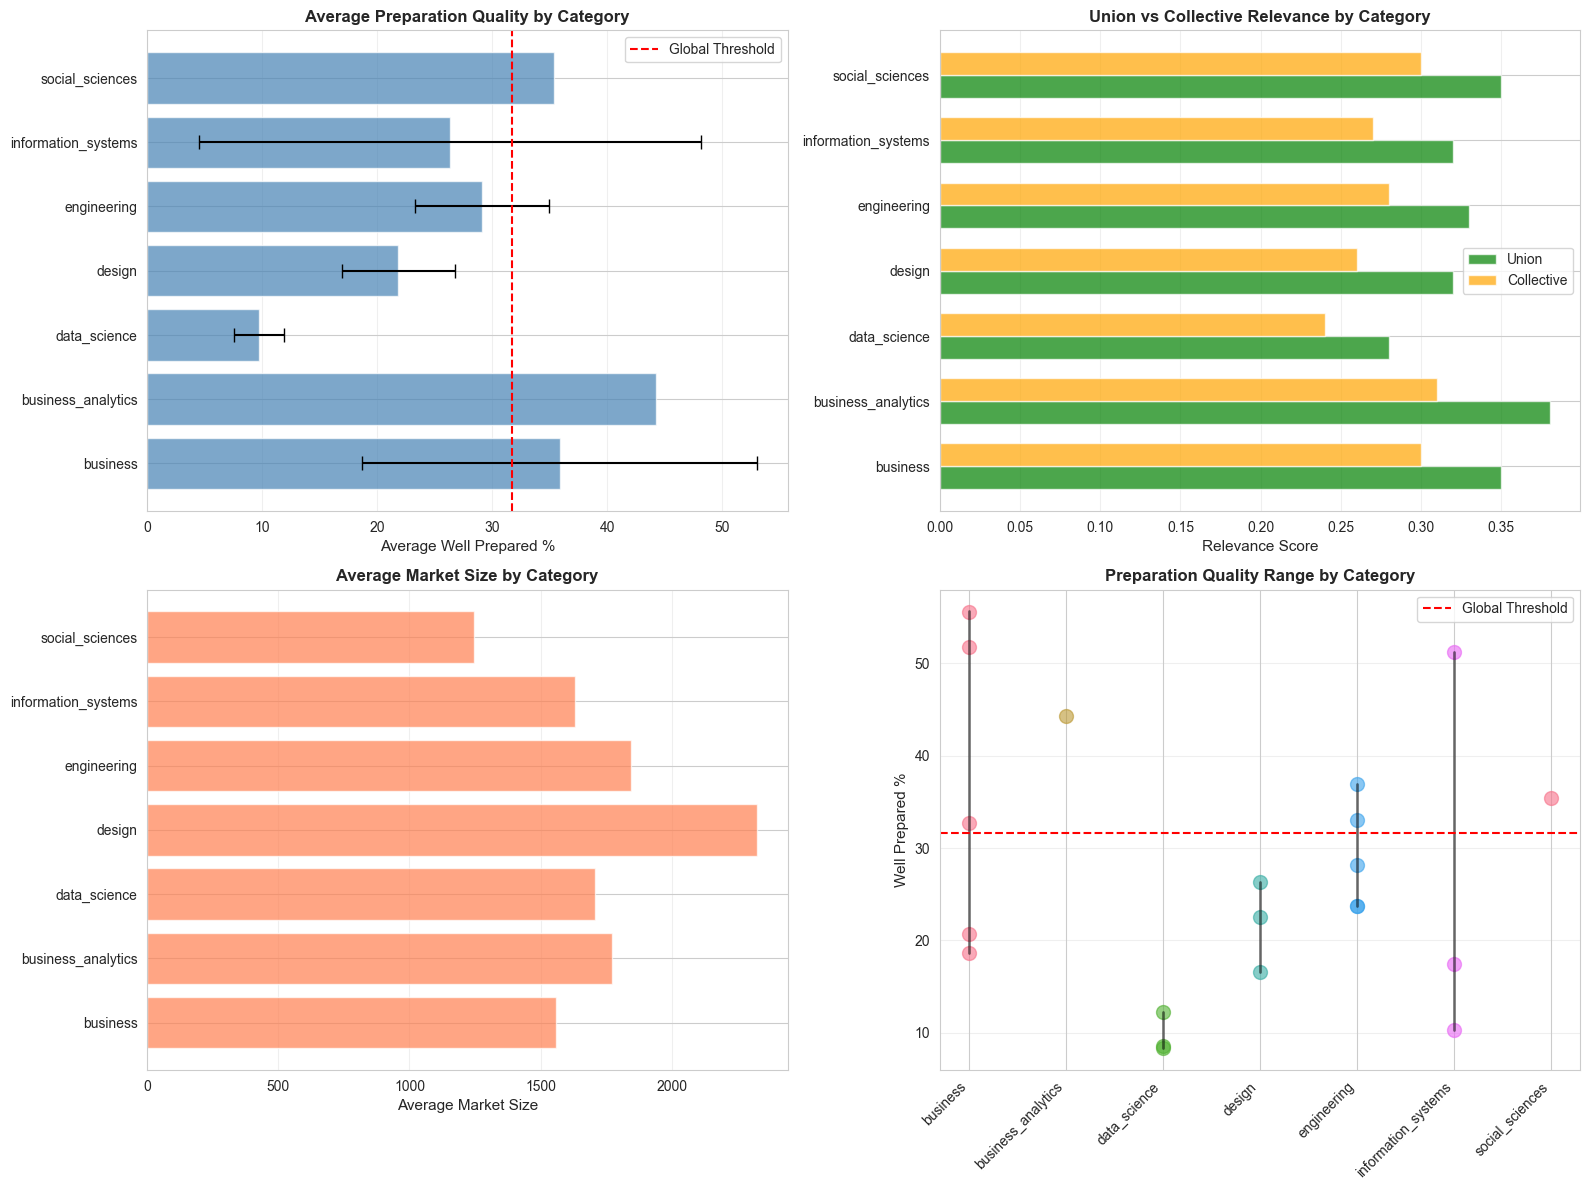

,category,well_prepared_pct_mean,well_prepared_pct_std,well_prepared_pct_min,well_prepared_pct_max,union_relevance_mean,collective_relevance_mean,market_size_mean
0,business,35.85,17.15,18.60,55.58,0.35,0.30,1559.8
1,business_analytics,44.24,NaN,44.24,44.24,0.38,0.31,1772.0
2,data_science,9.72,2.20,8.34,12.26,0.28,0.24,1706.0
3,design,21.80,4.91,16.57,26.32,0.32,0.26,2325.0
4,engineering,29.11,5.80,23.74,36.92,0.33,0.28,1843.0
5,information_systems,26.32,21.85,10.29,51.21,0.32,0.27,1630.0
6,social_sciences,35.36,NaN,35.36,35.36,0.35,0.30,1247.0


In [ ]:

# Category analysis
category_stats = comparison_data.groupby('category').agg({
    'well_prepared_pct': ['mean', 'std', 'min', 'max'],
    'union_relevance': 'mean',
    'collective_relevance': 'mean',
    'market_size': 'mean'
}).round(2)
# 
category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
category_stats = category_stats.reset_index()
# 
# Visualize category comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 
# Plot 1: Average well-prepared % by category
categories = category_stats['category'].values
avg_well_prep = category_stats['well_prepared_pct_mean'].values
std_well_prep = category_stats['well_prepared_pct_std'].values
# 
axes[0, 0].barh(categories, avg_well_prep, xerr=std_well_prep, 
                alpha=0.7, capsize=5, color='steelblue')
axes[0, 0].axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[0, 0].set_xlabel('Average Well Prepared %', fontsize=11)
axes[0, 0].set_title('Average Preparation Quality by Category', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
# 
# Plot 2: Union vs Collective relevance by category
x_pos = np.arange(len(categories))
width = 0.35
axes[0, 1].barh(x_pos - width/2, category_stats['union_relevance_mean'], 
                width, label='Union', alpha=0.7, color='green')
axes[0, 1].barh(x_pos + width/2, category_stats['collective_relevance_mean'], 
                width, label='Collective', alpha=0.7, color='orange')
axes[0, 1].set_yticks(x_pos)
axes[0, 1].set_yticklabels(categories)
axes[0, 1].set_xlabel('Relevance Score', fontsize=11)
axes[0, 1].set_title('Union vs Collective Relevance by Category', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)
# 
# Plot 3: Market size by category
axes[1, 0].barh(categories, category_stats['market_size_mean'], alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Average Market Size', fontsize=11)
axes[1, 0].set_title('Average Market Size by Category', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
# 
# Plot 4: Range of well-prepared % within each category
for i, cat in enumerate(categories):
    cat_data = comparison_data[comparison_data['category'] == cat]['well_prepared_pct'].values
    axes[1, 1].scatter([i] * len(cat_data), cat_data, s=100, alpha=0.6)
    axes[1, 1].plot([i, i], [category_stats.iloc[i]['well_prepared_pct_min'], 
                             category_stats.iloc[i]['well_prepared_pct_max']], 
                    'k-', linewidth=2, alpha=0.5)
# 
axes[1, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[1, 1].set_xticks(range(len(categories)))
axes[1, 1].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 1].set_ylabel('Well Prepared %', fontsize=11)
axes[1, 1].set_title('Preparation Quality Range by Category', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
# 
plt.tight_layout()
plt.show()
# 
# Display summary table
display(category_stats)

### Key Category Insights

Business degrees lead in preparation quality. Data science shows curriculum-market mismatch. Engineering varies by specialization. Design programs have specialized but smaller markets.

## Complete Ranking: All 21 Degrees

In [ ]:

# Full ranked table
ranked_df = comparison_data.sort_values('well_prepared_pct', ascending=False).reset_index(drop=True)
ranked_df['rank'] = ranked_df.index + 1
# 
# Select key columns for display
display_cols = ['rank', 'degree_full_name', 'school', 'category', 'market_size', 
                'union_relevance', 'collective_relevance', 'well_prepared_pct', 
                'moderately_prepared_pct', 'underprepared_pct']
# 
styled_df = ranked_df[display_cols].style\
    .background_gradient(subset=['well_prepared_pct'], cmap='RdYlGn', vmin=0, vmax=60)\
    .background_gradient(subset=['union_relevance', 'collective_relevance'], cmap='Blues')\
    .format({
        'union_relevance': '{:.3f}',
        'collective_relevance': '{:.3f}',
        'well_prepared_pct': '{:.1f}%',
        'moderately_prepared_pct': '{:.1f}%',
        'underprepared_pct': '{:.1f}%'
    })
# 
display(styled_df)

,rank,degree_full_name,school,category,market_size,union_relevance,collective_relevance,well_prepared_pct,moderately_prepared_pct,underprepared_pct
0,1,Singapore Management University - Business,smu,business,1085,0.386,0.335,55.6%,32.1%,12.4%
1,2,Singapore Management University - Accountancy,smu,business,1805,0.368,0.333,51.7%,39.3%,9.0%
2,3,National University of Singapore - Information Systems,nus,information_systems,1984,0.373,0.322,51.2%,35.1%,13.7%
3,4,National University of Singapore - Business Analytics,nus,business_analytics,1772,0.376,0.309,44.2%,41.0%,14.8%
4,5,National University of Singapore - Civil Engineering,nus,engineering,2744,0.345,0.302,36.9%,37.3%,25.8%
5,6,Singapore Management University - Social Sciences,smu,social_sciences,1247,0.346,0.299,35.4%,52.8%,11.9%
6,7,Singapore University of Technology and Design - Engineering Systems and Design,sutd,engineering,1333,0.326,0.279,33.0%,36.3%,30.7%
7,8,National University of Singapore - Accountancy,nus,business,2164,0.348,0.294,32.7%,44.6%,22.7%
8,9,National University of Singapore - Chemical Engineering,nus,engineering,1728,0.343,0.281,28.1%,44.8%,27.1%
9,10,National University of Singapore - Industrial Design,nus,design,1820,0.314,0.275,26.3%,40.7%,33.0%


## Summary

**Global Thresholds:** Well prepared ≥ 0.3166, Moderate: 0.2352-0.3166, Under-prepared < 0.2352

**Key Findings:**
1. Business programs lead with >50% well-prepared rates
2. Data science degrees lag despite high demand (curriculum mismatch)
3. School patterns: SMU specialized, NUS diverse/variable, SUTD interdisciplinary mixed
4. Market size and preparation quality show no correlation (r ≈ 0.0)
5. Top vs bottom 5 gap: 3.3x difference in preparation quality